# TP1 — Panorámica

## 3.6 Cálculo del tamaño óptimo para la imagen final

Las homografías pueden llevar las imágenes a coordenadas negativas o fuera del
ancho y alto del ancla. Calculamos el rectángulo mínimo con límites enteros que
contenga las tres imágenes transformadas y ajustamos sus homografías.

Las funciones están en `panorama_bounds.py`. Aquí mostramos su uso y comprobamos
los resultados, siguiendo las operaciones con coordenadas homogéneas de clase.


### Preparación del ejemplo

Usamos `inputs/cuadro_1.jpg` en los tres roles para aislar el cálculo geométrico.
La izquierda se desplaza −200 píxeles y la derecha +200 en x. El ancla conserva
su sistema de coordenadas. Se requieren NumPy, OpenCV y Matplotlib.


In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline

# Permite ejecutar desde la carpeta del notebook o desde la raíz del repo.
carpeta_tp = Path.cwd()
if not (carpeta_tp / "panorama_bounds.py").exists():
    carpeta_tp = carpeta_tp / "tp1_panoramica"
sys.path.insert(0, str(carpeta_tp))
from panorama_bounds import transform_corners, compute_panorama_bounds

imagen = cv2.imread(str(carpeta_tp / "inputs" / "cuadro_1.jpg"))
if imagen is None:
    raise ValueError("No se pudo cargar inputs/cuadro_1.jpg")
h, w = imagen.shape[:2]
print(f"Imagen de prueba: ancho={w}, alto={h}")


Imagen de prueba: ancho=3072, alto=4096


In [2]:
img_left = imagen
img_anchor = imagen
img_right = imagen

H_left = np.array([[1, 0, -200], [0, 1, 0], [0, 0, 1]], dtype=float)
H_right = np.array([[1, 0, 200], [0, 1, 0], [0, 0, 1]], dtype=float)
H_anchor = np.eye(3)


### Esquinas en el sistema del ancla

Para ancho **w** y alto **h** usamos `(0, 0), (w, 0), (w, h), (0, h)`.
Son límites geométricos; los índices de píxeles llegan hasta `w-1` y `h-1`.
La coordenada x indica columnas y la coordenada y indica filas.

Para cada esquina aplicamos `H @ [x, y, 1]` y dividimos las primeras dos
coordenadas por la tercera. Usamos las homografías hacia el ancla y la identidad
para el propio ancla.


In [3]:
esquinas_izquierda = transform_corners(img_left, H_left)
esquinas_ancla = transform_corners(img_anchor, H_anchor)
esquinas_derecha = transform_corners(img_right, H_right)

print("Izquierda en el sistema del ancla:\n", esquinas_izquierda)
print("Ancla:\n", esquinas_ancla)
print("Derecha en el sistema del ancla:\n", esquinas_derecha)


Izquierda en el sistema del ancla:
 [[-200.    0.]
 [2872.    0.]
 [2872. 4096.]
 [-200. 4096.]]
Ancla:
 [[   0.    0.]
 [3072.    0.]
 [3072. 4096.]
 [   0. 4096.]]
Derecha en el sistema del ancla:
 [[ 200.    0.]
 [3272.    0.]
 [3272. 4096.]
 [ 200. 4096.]]


### Límites y tamaño

Reunimos las 12 esquinas. Redondeamos hacia afuera para no recortar contenido:

```text
xmin = floor(min(x))       xmax = ceil(max(x))
ymin = floor(min(y))       ymax = ceil(max(y))
width = xmax - xmin        height = ymax - ymin
```

No sumamos 1 porque usamos límites `(w, h)`. Con identidad el tamaño debe ser
exactamente el original. El resultado usa el orden de OpenCV: `(ancho, alto)`.


In [4]:
resultado = compute_panorama_bounds(
    img_left, img_anchor, img_right, H_left, H_right
)
print("Límites (xmin, ymin, xmax, ymax):", resultado["bounds"])
print("Tamaño (ancho, alto):", resultado["size"])


Límites (xmin, ymin, xmax, ymax): (-200, 0, 3272, 4096)
Tamaño (ancho, alto): (3472, 4096)


### Traslación del conjunto

Si los mínimos son negativos, trasladamos **las tres imágenes por igual**:

```text
T = [[1, 0, -xmin],
     [0, 1, -ymin],
     [0, 0,     1]]
```

Así el extremo mínimo entero pasa al origen del canvas sin alterar la posición
relativa de las imágenes. En este ejemplo, `xmin = -200`, por lo que T suma 200 a x.


In [5]:
print("T:")
print(resultado["T"])


T:
[[  1.   0. 200.]
 [  0.   1.   0.]
 [  0.   0.   1.]]


### Composición de las transformaciones

Primero llevamos el punto de la imagen al sistema del ancla y después lo
trasladamos al canvas: `T @ (H @ punto) = (T @ H) @ punto`.
Por eso **`H_final = T @ H`**. Para el ancla, **`H_anchor_final = T`**,
porque su transformación inicial es la identidad.


In [6]:
for clave in ("H_left_final", "H_anchor_final", "H_right_final"):
    print(clave)
    print(resultado[clave])


H_left_final
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
H_anchor_final
[[  1.   0. 200.]
 [  0.   1.   0.]
 [  0.   0.   1.]]
H_right_final
[[  1.   0. 400.]
 [  0.   1.   0.]
 [  0.   0.   1.]]


### Esquinas antes y después de T

Comparamos las coordenadas en el sistema del ancla con las coordenadas finales.
Todas se desplazan +200 en x; sus coordenadas y permanecen iguales.


In [7]:
for clave in ("corners_anchor", "corners_final"):
    print(clave)
    for nombre, esquinas in resultado[clave].items():
        print(nombre)
        print(esquinas)


corners_anchor
left
[[-200.    0.]
 [2872.    0.]
 [2872. 4096.]
 [-200. 4096.]]
anchor
[[   0.    0.]
 [3072.    0.]
 [3072. 4096.]
 [   0. 4096.]]
right
[[ 200.    0.]
 [3272.    0.]
 [3272. 4096.]
 [ 200. 4096.]]
corners_final
left
[[   0.    0.]
 [3072.    0.]
 [3072. 4096.]
 [   0. 4096.]]
anchor
[[ 200.    0.]
 [3272.    0.]
 [3272. 4096.]
 [ 200. 4096.]]
right
[[ 400.    0.]
 [3472.    0.]
 [3472. 4096.]
 [ 400. 4096.]]


### Prueba 1: identidad

Si las tres imágenes coinciden y sus homografías son la identidad, el canvas
debe medir exactamente `(w, h)` y T no debe desplazar nada.


In [8]:
resultado_identidad = compute_panorama_bounds(
    imagen, imagen, imagen, np.eye(3), np.eye(3)
)
assert resultado_identidad["size"] == (w, h)
assert np.array_equal(resultado_identidad["T"], np.eye(3))
print("Prueba 1 OK: identidad conserva el tamaño original y T es identidad.")


Prueba 1 OK: identidad conserva el tamaño original y T es identidad.


### Prueba 2: traslaciones

El extremo izquierdo debe ser −200, T debe trasladar +200 y el ancho debe
crecer 400 píxeles. El alto se conserva. Comprobamos también las tres matrices
finales: sus desplazamientos en x deben ser 0, 200 y 400.


In [9]:
assert resultado["bounds"] == (-200, 0, w + 200, h)
assert resultado["size"] == (w + 400, h)
T_esperada = np.array([[1, 0, 200], [0, 1, 0], [0, 0, 1]])
assert np.array_equal(resultado["T"], T_esperada)
assert np.array_equal(resultado["H_left_final"], np.eye(3))
assert np.array_equal(resultado["H_anchor_final"], T_esperada)
assert np.array_equal(
    resultado["H_right_final"],
    np.array([[1, 0, 400], [0, 1, 0], [0, 0, 1]])
)
print("Prueba 2 OK: xmin=-200, traslación=+200 y ancho original+400.")


Prueba 2 OK: xmin=-200, traslación=+200 y ancho original+400.


### Prueba 3: esquinas dentro del canvas

Antes de T hay coordenadas negativas. Después de T, ninguna esquina debe
ser negativa ni superar el ancho o alto. Admitimos una pequeña tolerancia
numérica de `1e-7` píxeles en esta comprobación.

Los extremos alcanzan los cuatro bordes en este ejemplo: reducir el canvas
cortaría alguna imagen. Una esquina puede coincidir con el límite ancho/alto,
porque representa un borde geométrico, no un índice de píxel.


In [10]:
assert np.any(resultado["corners_anchor"]["left"][:, 0] < 0)
esquinas_finales = np.concatenate(list(resultado["corners_final"].values()))
ancho, alto = resultado["size"]
tolerancia = 1e-7
assert np.all(esquinas_finales >= -tolerancia)
assert np.all(esquinas_finales[:, 0] <= ancho + tolerancia)
assert np.all(esquinas_finales[:, 1] <= alto + tolerancia)
assert np.allclose(esquinas_finales.min(axis=0), [0, 0], atol=tolerancia)
assert np.allclose(esquinas_finales.max(axis=0), [ancho, alto], atol=tolerancia)
print("Prueba 3 OK: todas las esquinas entran y el canvas alcanza los extremos.")


Prueba 3 OK: todas las esquinas entran y el canvas alcanza los extremos.


### Visualización de los límites

Dibujamos las cuatro esquinas y el contorno de cada imagen después de T.
El rectángulo punteado muestra el canvas calculado. Como en una imagen,
x crece hacia la derecha e y hacia abajo. Sólo graficamos coordenadas.


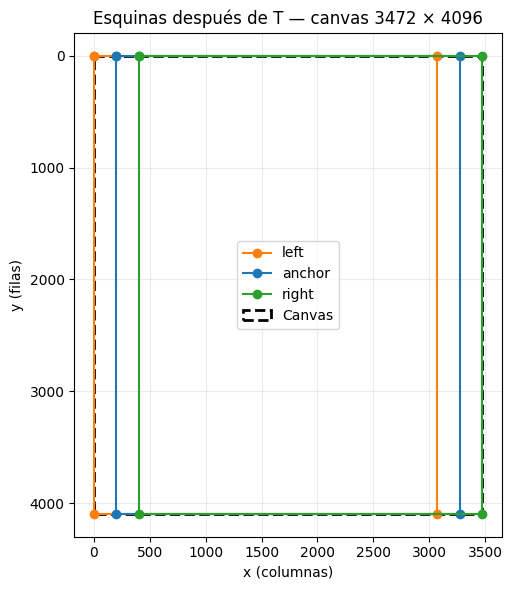

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, color in [("left", "tab:orange"), ("anchor", "tab:blue"), ("right", "tab:green")]:
    esquinas = resultado["corners_final"][nombre]
    contorno = np.vstack([esquinas, esquinas[0]])
    ax.plot(contorno[:, 0], contorno[:, 1], "o-", color=color, label=nombre)

ax.add_patch(Rectangle((0, 0), ancho, alto, fill=False,
                       edgecolor="black", linestyle="--", linewidth=2, label="Canvas"))
ax.set_title(f"Esquinas después de T — canvas {ancho} × {alto}")
ax.set_xlabel("x (columnas)")
ax.set_ylabel("y (filas)")
ax.set_aspect("equal")
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend(loc="center")
plt.tight_layout()
plt.show()


### Comparación: canvas ingenuo vs. canvas óptimo

Una primera aproximación es reservar `3w × h` para las tres imágenes. En este
ejemplo de traslaciones de ±200, ese tamaño alcanza una vez desplazado el
conjunto a coordenadas positivas, pero deja mucho espacio vacío. Una reserva
fija no considera dónde caen las imágenes después de sus homografías.

Comparamos esa reserva con `resultado["size"]`, ya calculado mediante las
esquinas. Medimos únicamente el número de píxeles del canvas. El `assert`
comprueba el ahorro **en este ejemplo**; no supone que `3w × h` alcance para
cualquier homografía.


In [12]:
naive_width = 3 * w
naive_height = h
panorama_width, panorama_height = resultado["size"]

area_ingenua = naive_width * naive_height
area_optima = panorama_width * panorama_height
ahorro = area_ingenua - area_optima
reduccion_porcentual = 100 * ahorro / area_ingenua

print("Canvas ingenuo:", (naive_width, naive_height))
print("Canvas óptimo:", resultado["size"])
print(f"Píxeles reservados (ingenuo): {area_ingenua:,}")
print(f"Píxeles reservados (óptimo): {area_optima:,}")
print(f"Ahorro: {ahorro:,} píxeles ({reduccion_porcentual:.2f}% menos)")
assert area_optima <= area_ingenua
print("Comprobación OK: en este ejemplo, el canvas óptimo reserva menos espacio.")


Canvas ingenuo: (9216, 4096)
Canvas óptimo: (3472, 4096)
Píxeles reservados (ingenuo): 37,748,736
Píxeles reservados (óptimo): 14,221,312
Ahorro: 23,527,424 píxeles (62.33% menos)
Comprobación OK: en este ejemplo, el canvas óptimo reserva menos espacio.


#### Comparación visual

Usamos `resultado["corners_final"]` en ambos gráficos: la misma traslación T
ubica las tres imágenes en coordenadas positivas y permite comparar sólo el
tamaño reservado. Conservamos la misma escala en los dos ejes.

El rectángulo blanco punteado es el canvas. La zona gris queda **fuera** del
canvas y no se reserva. Los polígonos representan las imágenes; no se transforma
ninguna imagen ni se crea una matriz del tamaño de los canvas.


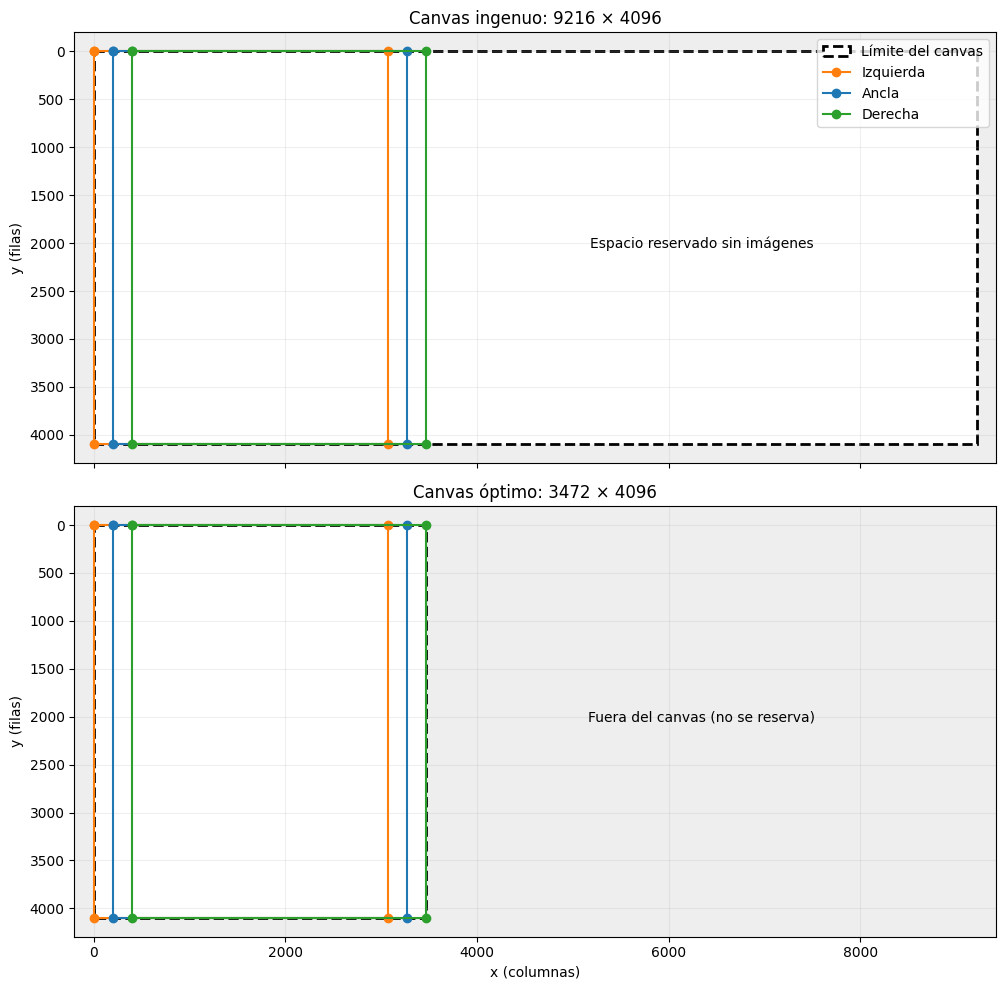

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True, sharey=True)

for ax, titulo, canvas_width, canvas_height in [
    (axes[0], "Canvas ingenuo", naive_width, naive_height),
    (axes[1], "Canvas óptimo", panorama_width, panorama_height),
]:
    ax.set_facecolor("#eeeeee")
    ax.add_patch(Rectangle(
        (0, 0), canvas_width, canvas_height,
        facecolor="white", edgecolor="black", linestyle="--", linewidth=2,
        label="Límite del canvas"
    ))
    for nombre, etiqueta, color in [
        ("left", "Izquierda", "tab:orange"),
        ("anchor", "Ancla", "tab:blue"),
        ("right", "Derecha", "tab:green"),
    ]:
        esquinas = resultado["corners_final"][nombre]
        contorno = np.vstack([esquinas, esquinas[0]])
        ax.plot(contorno[:, 0], contorno[:, 1], "o-", color=color, label=etiqueta)

    ax.set_title(f"{titulo}: {canvas_width} × {canvas_height}")
    ax.set_xlim(-200, naive_width + 200)
    ax.set_ylim(naive_height + 200, -200)
    ax.set_aspect("equal")
    ax.set_ylabel("y (filas)")
    ax.grid(alpha=0.2)

x_texto = (panorama_width + naive_width) / 2
axes[0].text(x_texto, h / 2, "Espacio reservado sin imágenes", ha="center")
axes[1].text(x_texto, h / 2, "Fuera del canvas (no se reserva)", ha="center")
axes[0].legend(loc="upper right")
axes[1].set_xlabel("x (columnas)")
plt.tight_layout()
plt.show()


#### Conclusión

El canvas ingenuo contiene las imágenes de este ejemplo, pero deja una franja
vacía grande a la derecha: reserva espacio sin considerar sus posiciones reales.
En el segundo gráfico, el canvas termina justo donde termina el contenido;
la región gris exterior ya no forma parte del espacio reservado.

Calcular `xmin`, `ymin`, `xmax` y `ymax` a partir de las esquinas adapta el tamaño
a las homografías y elimina los bordes sobrantes sin cortar contenido. Por eso
la solución final sigue siendo `compute_panorama_bounds(...)`; el canvas ingenuo
sólo ilustra el costo de elegir un tamaño fijo.


### Referencias de las tutoriales

Seguimos `homo`, `cart` y `apply_transform` de
`../tutorial_codigos/homo_utils copy.py`, y los ejemplos de homografías,
composición y cálculo de bordes de `homografias copy.ipynb` y
`transformaciones copy.ipynb`, en esa misma carpeta.
Usamos `floor`/`ceil` en lugar del `round` del ejemplo para redondear hacia afuera.


### Integración con las etapas anteriores

Cuando estén integradas las etapas de matching, RANSAC y DLT, reemplazaremos
las matrices de prueba por `H_izq_ancla` y `H_der_ancla`. Ambas deben transformar
**hacia el ancla** y corresponder a las mismas dimensiones y recortes de las
imágenes recibidas.

La llamada será la siguiente. Se deja como ejemplo en Markdown, sin ejecutar,
porque todavía no están disponibles las homografías reales:

```python
result = compute_panorama_bounds(
    img_left,
    img_anchor,
    img_right,
    H_izq_ancla,
    H_der_ancla
)
```

Se obtendrán `result["size"]` y las tres homografías ajustadas para la etapa
siguiente. Esta sección termina en el cálculo geométrico del ítem 3.6.
